In [2]:
from pathlib import Path

import prism

from imagematerials.factory import ModelFactory, Sector
from imagematerials.model import (
    GenericMaterials,
    GenericStocks,
    MaterialIntensities,
    RestOf, 
    SharesInflowStocks
)
from imagematerials.preprocessing import get_preprocessing_data

from imagematerials.rest_of import rest_of_preprocessing

from imagematerials.electricity.preprocessing import (
    get_preprocessing_data_gen,
    get_preprocessing_data_grid,
    get_preprocessing_data_stor
)

In [3]:
YEAR_START = 1971  # start year of the simulation period
YEAR_END = 2100    # end year of the calculations
YEAR_OUT = 2100    # year of output generation = last year of reporting

In [4]:
scenario_list = {
    "SSP2_M_CP":("SSP2_M_CP", None)
                 }

    # "SSP2_VLLO":("SSP2_VLLO", None),
    # "SSP2_VLLO_LifeTech":("SSP2_VLLO_LifeTech", ["resource_efficient"]

In [5]:
path_image_scenarios = Path("..", "data", "raw", "image")
scenario_base_path = Path("..", "data", "raw", "circular_economy_scenarios")
path_raw_data = Path("..", "data", "raw")
path_image_materials = Path("..")

In [6]:
model_runs = {}

for scen_id, (climate_scen, circular_scen) in scenario_list.items():
    print(f"Running scenario: {scen_id}")
    print(f"Circular economy scenario: {circular_scen}")
    print('Current path: ', Path.cwd())

    # needed for electricity
    scen = climate_scen.split("_")[0]
    variant = "_".join(climate_scen.split("_")[1:])
    
    climate_policy_scenario_dir = path_image_scenarios / climate_scen
    if circular_scen is not None:
        circular_economy_dir = {
            scenario: scenario_base_path / scenario for scenario in circular_scen
        }
    else:
        circular_economy_dir = None

    # Define the complete timeline, including historic tail
    time_start = 1971
    complete_timeline = prism.Timeline(time_start, 2100, 1)
    simulation_timeline = prism.Timeline(1971, 2100, 1)

    # BUILDINGS
    bld_sector = get_preprocessing_data("buildings", path_raw_data, 
                                        climate_policy_scenario_dir, 
                                        circular_economy_scenario_dirs = circular_economy_dir) 
    # VEHICLES
    vhc_sector = get_preprocessing_data("vehicles", path_raw_data, 
                                        climate_policy_scenario_dir, 
                                        circular_economy_scenario_dirs = circular_economy_dir)
    prep_data_vhc = vhc_sector.prep_data
    vhc_sector = Sector('vehicles', prep_data_vhc)

    # GENERATION
    prep_data_gen = get_preprocessing_data_gen(path_image_materials, scen, variant, YEAR_START, YEAR_END, YEAR_OUT)
    sec_electr_gen = Sector("generation", prep_data_gen)
    
    # GRID
    prep_data_lines, prep_data_add = get_preprocessing_data_grid(path_image_materials, scen, variant, YEAR_START, YEAR_END, YEAR_OUT)
    sec_electr_grid_lines = Sector("grid", prep_data_lines)
    sec_electr_grid_add = Sector("grid_additional", prep_data_add)
   
    # STORAGE
    prep_data_phs, prep_data_oth_storage = get_preprocessing_data_stor(path_image_materials, scen, variant, YEAR_START, YEAR_END, YEAR_OUT)
    sec_electr_stor_phs = Sector("storage_pumped_hydropower", prep_data_phs)
    sec_electr_stor_oth = Sector("storage_other", prep_data_oth_storage)

    # REST OF SECTOR
    rest_sector = rest_of_preprocessing(path_raw_data, 
                        image_scenario_directory = climate_policy_scenario_dir, 
                        scenario = climate_scen)
    rest_sector = Sector(name='rest_of', data = rest_sector)
    

    factory = ModelFactory(
    [bld_sector, vhc_sector, sec_electr_gen, rest_sector, 
     sec_electr_grid_lines, sec_electr_grid_add, sec_electr_stor_phs, sec_electr_stor_oth], complete_timeline
    ).add(GenericStocks, ["buildings", "vehicles", "generation", "grid", "grid_additional", 'storage_pumped_hydropower'] 
    ).add(GenericMaterials,  "vehicles"
    ).add(SharesInflowStocks, "storage_other"
    ).add(MaterialIntensities, ["buildings", "generation", "grid", "grid_additional", 
                                "storage_pumped_hydropower", "storage_other"] 
    ).add(RestOf, "rest_of", input_sources={
        "gompertz_coefs": "rest_of",
        "gdp_per_capita": "rest_of",
        "population": "rest_of",
        "historic_diff_consumption_mean": "rest_of",
        "historic_diff_consumption_total": "rest_of"
}
    )
    model = factory.finish()
    model_runs[climate_scen] = model

    import warnings
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        model.simulate(simulation_timeline)
        model.save_pkl(f'model_results/{scen_id}_model.pkl')



Running scenario: SSP2_M_CP
Circular economy scenario: None
Current path:  c:\Coding\image-materials\examples
Path to image output: ..\data\raw\image\SSP2_M_CP\EnergyServices


c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


grid_stock_lines to xarray Dataset
materials_grid_kgperkm to xarray Dataset
lifetime_grid_distr not in conversion_table
grid_stock_add to xarray Dataset
materials_grid_add_kgperunit to xarray Dataset
lifetime_grid_distr not in conversion_table
Path to image output: ..\data\raw\image\SSP2_M_CP\EnergyServices
phs_stock to xarray Dataset
phs_materials to xarray Dataset
phs_lifetime_distr not in conversion_table
oth_storage_stock to xarray Dataset
oth_storage_lifetime_distr not in conversion_table
oth_storage_shares to xarray Dataset


In [100]:
from imagematerials.rest_of.util import sum_inflows_for_all_sectors

base_run = ModelFactory.load_pkl(f"model_results/SSP2_M_CP_model.pkl")

total_inflow = sum_inflows_for_all_sectors(base_run, 'inflow_materials')


In [104]:
total_inflow.sel(material='steel').sum('Type').sel(Region = 'USA')

Magnitude,[701211234914.3715 40930910423.92482 43186946953.8166 10560250375.818136 10118867776.237896 47961325914.3669 42180797521.97728 47341001446.613976 45662844313.2276 28693616450.19138 24539180713.07097 16506469734.540188 61186987945.13927 58419479533.1031 61555156226.69248 60729655725.46516 57714899892.2485 68785413545.30516 52401609334.386826 36011178865.91946 31031502755.633526 48988796042.35183 52288099376.92096 53040321322.65056 51031704552.57015 59346060216.565994 69585942831.41351 71980034276.46548 65436296157.68345 59998021581.304825 51972757342.74515 46090757153.35056 53983377662.66277 57072487608.39691 64771942911.218 56820934114.059166 55611482557.324295 36173350803.93382 33572163387.284584 70940254090.946 64990627915.24721 66133087663.42254 73263983800.09012 70481594868.2307 85911022473.28467 71189982167.50865 62826856528.76186 71855705379.67456 62478409559.08649 26917856461.74093 87025480410.7852 72306988250.06624 65292243057.1128 63859241819.89221 65247664809.21099 64815421415.33696 62680624932.21211 63102215639.44916 67692917346.8982 74134423644.19284 65311831159.04045 62938617008.758415 61769813781.80554 63372470532.81632 64917743883.51255 71687174320.52158 79613305776.84482 81154919846.5568 94107295354.1502 99583441222.89813 93746201259.04436 93616958937.87923 96446631790.1848 101287176139.68188 102582449344.39102 101424508979.45682 102608649194.75166 113828137399.2508 119723851633.16766 117392345900.59882 121121741488.78793 125754875125.25882 117174577651.53046 110330828849.91672 106260608275.45885 105539089996.9769 103757710859.94276 98981025891.56248 89507945973.06757 88099404951.38861 90887402261.51126 91422029678.12868 92794674606.17368 95315102341.07347 100814001292.09044 103808659974.97151 105970563962.8567 107023405359.52544 110188380840.82115 114295825917.69434 113276755908.85416 112988931395.18814 115520790667.26689 119105194576.7603 118232633485.20108 116339603050.59515 117955406765.60228 117697076082.26048 117134295955.61343 115439154454.32007 111054085527.63765 109849045887.895 109204516763.2612 107299488229.58502 106732110655.8347 107249240611.06908 110830652228.49239 107520487742.87868 101100406866.1485 98600502163.49132 100969049599.6861 106276510382.54944 102847740898.14682 96054557268.23576 97425215319.32103 94783811684.5058 92871817309.78986 96811187345.1104 99063394866.71996 101566466399.79181]
Units,kilogram


In [105]:
numeric_region_map = {
    "CAN" : 'class_ 1',
    "USA": 'class_ 2',
    "MEX": 'class_ 3',
    "RCAM": 'class_ 4',
    "BRA": 'class_ 5',
    "RSAM": 'class_ 6',
    "NAF": 'class_ 7',
    "WAF": 'class_ 8',
    "EAF": 'class_ 9',
    "SAF": 'class_ 10',
    "WEU": 'class_ 11',
    "CEU": 'class_ 12',
    "TUR": 'class_ 13',
    "UKR": 'class_ 14',
    "STAN": 'class_ 15',
    "RUS": 'class_ 16',
    "ME": 'class_ 17',
    "INDIA": 'class_ 18',
    "KOR": 'class_ 19',
    "CHN": 'class_ 20',
    "SEAS": 'class_ 21',
    "INDO": 'class_ 22',
    "JAP": 'class_ 23',
    "OCE": 'class_ 24',
    "RSAS": 'class_ 25',
    "RSAF": 'class_ 26'
    }


In [106]:
# detect Region coord name (case variations) and apply mapping
dim = "Region" if "Region" in total_inflow.coords else "region"
old_regions = [str(r) for r in total_inflow.coords[dim].values]

# ensure mapping keys are strings
map_str = {str(k): v for k, v in numeric_region_map.items()}
new_labels = [map_str.get(r, r) for r in old_regions]

# assign new labels, aggregate duplicates, then ensure class_ 1..class_26 exist
total_inflow = total_inflow.assign_coords({dim: ("Region", new_labels)})  # keep dim name consistent
total_inflow = total_inflow.groupby(dim).sum()

desired = [f"class_ {i}" for i in range(1, 27)]
total_inflow = total_inflow.reindex({dim: desired}, fill_value=0)

In [ ]:
 # TODO: for now still use class_ 1, later change to country names

# save steel
inflow_steel = total_inflow.sel(material="steel").sum('Type')
# convert to tons with pint
inflow_steel = inflow_steel.pint.to('ton')
# save with years as rows and regions as columns
inflow_steel.name = "inflow_steel"
# # drop material and Type dimensions
# inflow_steel = inflow_steel.reset_coords(['material'], drop=True)

# # save as CSV
# test = inflow_steel.to_dataframe().unstack(dim)
# # drop material and Type dims
# test.to_csv("../data/rawimage_materials_steel.csv")

# detect region dim name
region_dim = "Region" if "Region" in inflow_steel.coords else "region"
time_dim = "Time" if "Time" in inflow_steel.coords else "time"

# convert to tidy DataFrame then pivot so index = time and columns = class_ 1..class_26
df_tidy = inflow_steel.to_dataframe(name="value").reset_index()
df_pivot = df_tidy.pivot(index=time_dim, columns=region_dim, values="value")

# ensure exact column order and fill missing classes with 0
desired = [f"class_ {i}" for i in range(1, 27)]
df_pivot = df_pivot.reindex(columns=desired, fill_value=0)

# name the index column "time" in the CSV header
df_pivot.index.name = "time"

# write CSV
df_pivot.to_csv("../data/raw/rest-of/metals/image_materials_steel.csv")

c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


In [111]:
test

inflow_steel                                                          \
Region      class_ 1      class_ 2      class_ 3      class_ 4      class_ 5   
time                                                                           
1971    8.641728e+07  7.729531e+08  8.273139e+07  1.769273e+07  8.577505e+07   
1972    4.708099e+06  4.511861e+07  4.681072e+06  5.781131e+05  8.834033e+06   
1973    4.973861e+06  4.760546e+07  5.089090e+06  8.121905e+05  1.108247e+07   
1974    4.071869e+06  1.164068e+07  4.108213e+06  3.969349e+05  1.124514e+07   
1975    3.524155e+06  1.115414e+07  4.094468e+06  6.255304e+05  4.667438e+06   
...              ...           ...           ...           ...           ...   
2096    1.418669e+07  1.044813e+08  3.264961e+07  1.764295e+07  5.938302e+07   
2097    1.406154e+07  1.023737e+08  3.353940e+07  1.755952e+07  6.001323e+07   
2098    1.441139e+07  1.067161e+08  4.110251e+07  1.773660e+07  5.841093e+07   
2099    1.476024e+07  1.091987e+08  3.343060e+07  1.814489e+07  5.800578e+07   
2100    1.470809e+07  1.119579e+08  3.278546e+07  1.831849e+07  5.688550e+07   

                                                                              \
Region      class_ 6      class_ 7      class_ 8      class_ 9     class_ 10   
time                                                                           
1971    1.345408e+08  5.126831e+07  3.550561e+07  2.018346e+07  3.197373e+07   
1972    3.899495e+06  2.259539e+06  1.139488e+06  5.495410e+05  8.443008e+05   
1973    3.988412e+06  1.290286e+06  1.296244e+06  5.879697e+05  8.974884e+05   
1974    3.451735e+06  1.166242e+06  1.274357e+06  7.626313e+05  4.260314e+05   
1975    4.587048e+06  2.148821e+06  1.512398e+06  8.260979e+05  1.245574e+06   
...              ...           ...           ...           ...           ...   
2096    4.927548e+07  7.664300e+07  2.270768e+08  1.045123e+08  1.667482e+07   
2097    4.856931e+07  7.734100e+07  2.298801e+08  1.032197e+08  1.669314e+07   
2098    4.796302e+07  7.689102e+07  2.310224e+08  1.036945e+08  1.669649e+07   
2099    4.820267e+07  7.669404e+07  2.325077e+08  1.033886e+08  1.656805e+07   
2100    4.918778e+07  7.813698e+07  2.351575e+08  1.010024e+08  1.657874e+07   

        ...                                                          \
Region  ...     class_ 17     class_ 18     class_ 19     class_ 20   
time    ...                                                           
1971    ...  1.033025e+08  2.722454e+08  3.976860e+07  3.719744e+08   
1972    ...  8.418835e+06  6.203052e+06  1.011330e+06  9.989038e+06   
1973    ...  3.800727e+06  5.569871e+06  1.740201e+06  1.106009e+07   
1974    ...  1.752312e+06  7.766640e+06  1.958687e+06  1.071070e+07   
1975    ...  3.972790e+06  8.794390e+06  1.547324e+06  1.025573e+07   
...     ...           ...           ...           ...           ...   
2096    ...  8.542839e+07  1.975653e+08  7.529771e+06  1.702004e+08   
2097    ...  8.470087e+07  1.986227e+08  7.159459e+06  1.714908e+08   
2098    ...  8.505755e+07  1.990206e+08  6.934758e+06  1.684174e+08   
2099    ...  8.577842e+07  1.994732e+08  6.831777e+06  1.657065e+08   
2100    ...  8.564478e+07  2.003302e+08  6.746737e+06  1.597911e+08   

                                                                              \
Region     class_ 21     class_ 22     class_ 23     class_ 24     class_ 25   
time                                                                           
1971    9.421215e+07  2.364889e+07  2.092736e+08  6.621163e+07  2.951712e+07   
1972    2.537952e+06  9.565638e+05  1.513777e+07  1.722516e+06  5.659510e+05   
1973    2.832647e+06  9.890466e+05  1.571309e+07  2.852055e+06  5.956340e+05   
1974    2.578580e+06  1.215308e+06  6.694800e+06  3.278136e+06  1.186742e+06   
1975    2.951691e+06  1.336888e+06  1.532196e+07  1.808759e+06  1.059722e+06   
...              ...           ...           ...           ...           ...   
2096    7.220006e+07  4.479021e+07  2.203201e+07  1

In [79]:
inflow_steel

Magnitude,[[78396433166.47478 0.0 75052653750.1385 ... 60066179383.05777 26777482058.74357 11757506086.986736] [4271115206.563064 0.0 4246597010.3656597 ... 1562640120.7796903 513422127.8717087 483689317.55263025] [4512210607.814941 0.0 4616744782.090945 ... 2587340916.7166862 540350050.005533 509480965.82761043] ... [13073788988.64004 0.0 37287570895.3329 ... 17445939884.80389 102959759472.31096 74991402845.01207] [13390263503.1989 0.0 30327733863.67579 ... 18390971017.064877 101485082441.32559 77016861877.80586] [13342952835.782219 0.0 29742470481.55265 ... 16975039743.788757 109806457135.2722 77888605559.03526]]
Units,kilogram


c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
C:\Users\Arp00003\AppData\Local\Temp\ipykernel_25832\3531115014.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab20 = plt.cm.get_cmap('tab20')(np.linspace(0, 1, 20))
C:\Users\Arp00003\AppData\Local\Temp\ipykernel_25832\3531115014.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab20b = plt.cm.get_cmap('tab20b')(np.linspace(0, 1, 20))
C:\Users\Arp00003\AppData\Local\Temp\ipykernel_25832\3531115014.py:18: Mat

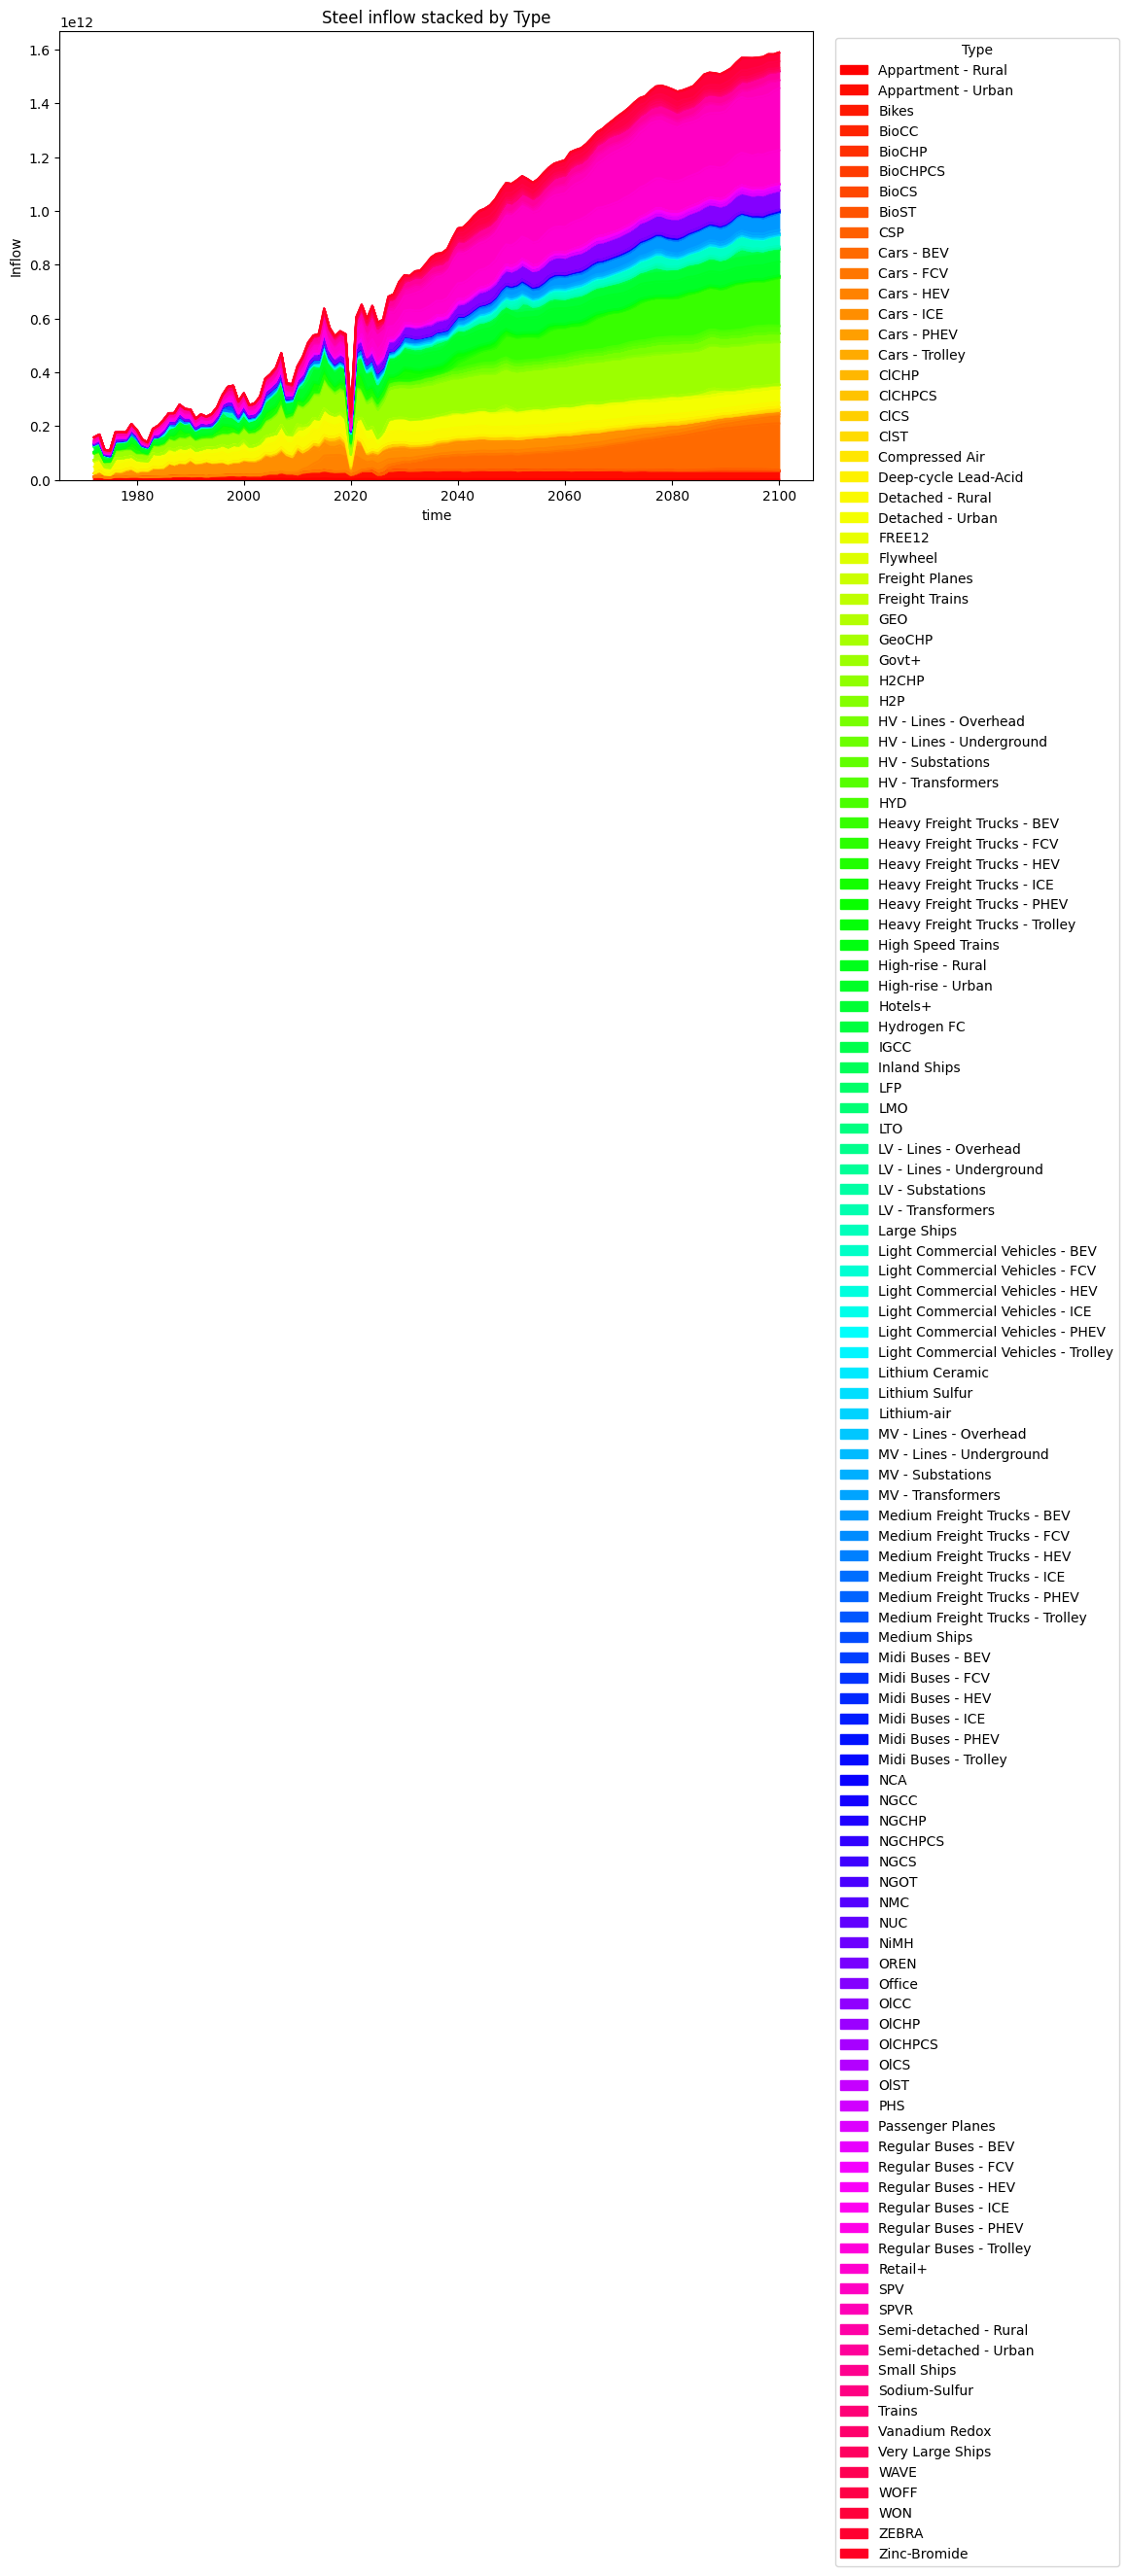

In [10]:
# plot steel inflow stacked by Type (preserves Type dimension) with unique colors
df = total_inflow.sel(material='steel').sum('Region').loc[1972:].fillna(0).to_pandas()

# ensure predictable column order and string labels
df = df.astype(float)
df.columns = [str(c) for c in df.columns]
df = df.reindex(columns=sorted(df.columns))

import matplotlib.pyplot as plt
import numpy as np

ncols = len(df.columns)

# build a palette: try concatenating tab20 / tab20b / tab20c, else sample a continuous map
try:
    tab20 = plt.cm.get_cmap('tab20')(np.linspace(0, 1, 20))
    tab20b = plt.cm.get_cmap('tab20b')(np.linspace(0, 1, 20))
    tab20c = plt.cm.get_cmap('tab20c')(np.linspace(0, 1, 20))
    base_colors = np.vstack([tab20, tab20b, tab20c])
except Exception:
    # fallback if some maps not available
    base_colors = plt.cm.get_cmap('tab20')(np.linspace(0, 1, max(20, ncols)))

if ncols <= base_colors.shape[0]:
    colors = [tuple(c) for c in base_colors[:ncols]]
else:
    # if still not enough, sample a continuous hue map (hsv) for distinct colors
    cmap = plt.cm.get_cmap('hsv')
    colors = [cmap(i / ncols) for i in range(ncols)]

fig, ax = plt.subplots(figsize=(10, 6))
df.plot.area(ax=ax, stacked=True, color=colors)
ax.set_ylabel('Inflow')
ax.set_title('Steel inflow stacked by Type')
ax.legend(title='Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()